In [ ]:
# 1. Install duckdb so we can run SQL inside Python
!pip install duckdb-engine --quiet

# 2. Load the SQL tool into our notebook
%load_ext sql

# 3. Create a temporary in-memory database connection
%sql duckdb:///:memory:

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.7/49.7 kB 1.4 MB/s eta 0:00:00
The sql extension is already loaded. To reload it, use:
  %reload_ext sql


In [ ]:
import pandas as pd
df = pd.read_csv("netflix_titles.csv")
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [ ]:
df['type'].value_counts()

,count
type,
Movie,6131
TV Show,2676


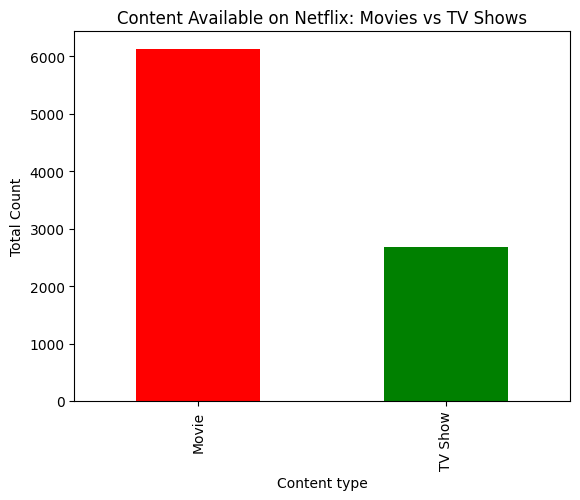

In [ ]:
import matplotlib.pyplot as plt
type_counts = df['type'].value_counts()
type_counts.plot(kind='bar', color=['red','green'])
plt.title("Content Available on Netflix: Movies vs TV Shows")
plt.ylabel("Total Count")
plt.xlabel("Content type")
plt.show()

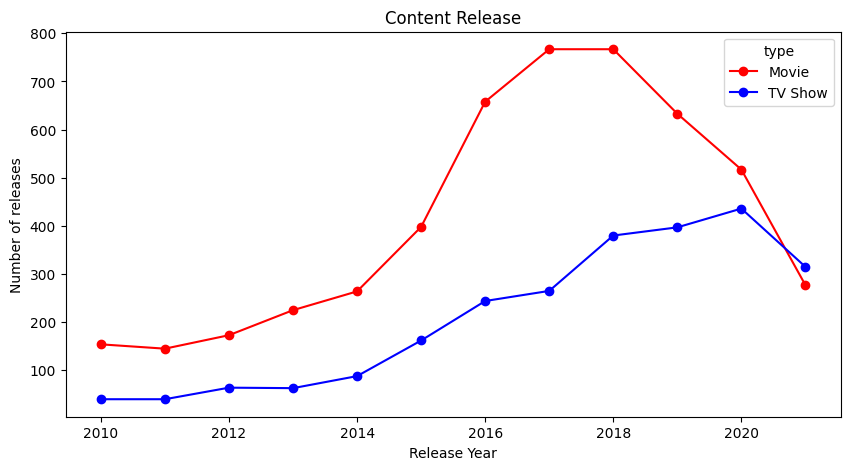

In [ ]:
recent_df = df[(df['release_year'] >= 2010) & (df['release_year'] <= 2021)]
trend = recent_df.groupby(['release_year','type']).size().unstack()
trend.plot(kind = 'line', marker = 'o', color=["red","blue"], figsize=(10,5))
plt.title("Content Release")
plt.ylabel("Number of releases")
plt.xlabel("Release Year")
plt.show()

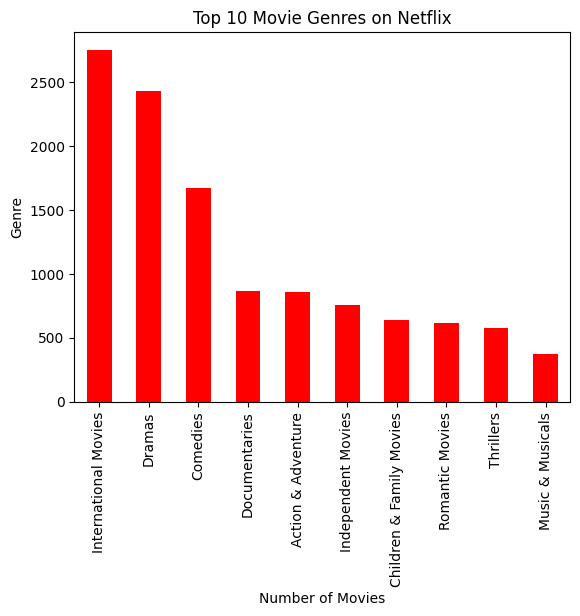

In [ ]:
movies = df[df['type'] == 'Movie']
all_genres = movies['listed_in'].str.split(', ').explode()
top_genres = all_genres.value_counts().head(10)
top_genres.plot(kind='bar', color='red')
plt.title('Top 10 Movie Genres on Netflix')
plt.xlabel('Number of Movies')
plt.ylabel('Genre')
plt.show()

In [ ]:
clean_directors = movies['director'].dropna()
all_directors = clean_directors.str.split(', ').explode()
top_directors = all_directors.value_counts().head(5)
print("Top 5 Directors on Netflix", top_directors)

Top 5 Directors on Netflix director
Rajiv Chilaka    22
Jan Suter        21
Raúl Campos      19
Suhas Kadav      16
Marcus Raboy     15
Name: count, dtype: int64
